In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
from scipy.signal import savgol_filter
from simu import simulate_roll_truth

Gyro gives roll rate $\omega$ and is integrated to get roll angle. We need a bias term so that angle will not drift. With only the gyroscope, absolute roll angle is not directly measurable, only relative roll. This filter implementation will leave open opportunities for magnetometer or other measurment methods to obtain absolute angles if possible.

The new state vector will be ($\phi$, $\omega$, $b$) where $\omega$ is the true roll rate and $\phi$ is relative.

Dynamics:

$\phi_{k+1} = \phi_{k} + \omega_{k}dt$

$\omega_{k+1} = \omega_{k} + w_{\omega}$ 

$b_{k+1} = b_{k} + w_{b}$

Measurement model:

$z_k = \omega_k + b_k + v_k$

### Q and R estimation

### Kalman Filter

In [139]:
class KF:
    def __init__(self, dt, x0, P0, Q, R):#q_alpha, r_phi, r_omega):
        
        self.x = np.array([[x0[0]], [x0[1]], [x0[2]]]) # (phi, omega, bias)
        self.dt = dt
        # state estimation matrix
        self.F = np.array([[1, dt, 0],
                           [0, 1, 0],
                           [0, 0, 1]])
        # control input
        I = 1
        self.G = np.array([[0],[self.dt / I], [0]])
        # measurement model
        self.H = np.array([[0, 1, 1]])
        # covariances 
        # self.Q = np.array([[dt**5 / 20, dt**4 / 8, dt**3 / 6],
        #                    [dt**4 / 8,  dt**3 / 3, dt**2 / 2],
        #                    [dt**3 / 6,  dt**2 / 2, dt]]) * q_alpha**2
        self.Q = Q
        self.R = R

        # state estimation error covariance
        self.P = P0
        
        # for reproducability
        self.rng = np.random.default_rng(3)

    
    def predict(self, u=0): # no control input (torque) for now
       # w_omega = self.rng.normal(0, (self.Q[1,1]/self.dt)**0.5) #np.array([[0], [0], [self.q_alpha**2]]) # random white noise
      #  w_b = self.rng.normal(0, self.Q[2,2]) #(self.Q[2,2]*3600/self.dt)**0.5)
        w_k = 0#self.rng.multivariate_normal([0,0,0], self.Q * self.dt)[:, np.newaxis]
        self.x = self.F @ self.x + w_k#np.array([[0], [w_omega], [w_b]])
        self.P = self.F @ self.P @ self.F.T + self.Q
        print(self.P)
        return self.x.copy(), self.P.copy()
    
    def update(self, z):
        y = z - (self.H @ self.x) # innovation
        S = self.H @ self.P @ self.H.T + self.R # innovation variance
        K = self.P @ self.H.T @ np.linalg.inv(S) # Kalman gain
        # print(self.P)
        # print(self.H)
        # print(S)
        #print(K)
        # print(self.x)
        # print(y)
        # print(K)
        self.x = self.x + K * y
        self.P = (np.eye(3) - K @ self.H) @ self.P
        return y, S


In [36]:
a = np.array([1,2,3])
a[:, np.newaxis]

array([[1],
       [2],
       [3]])

### Old Data

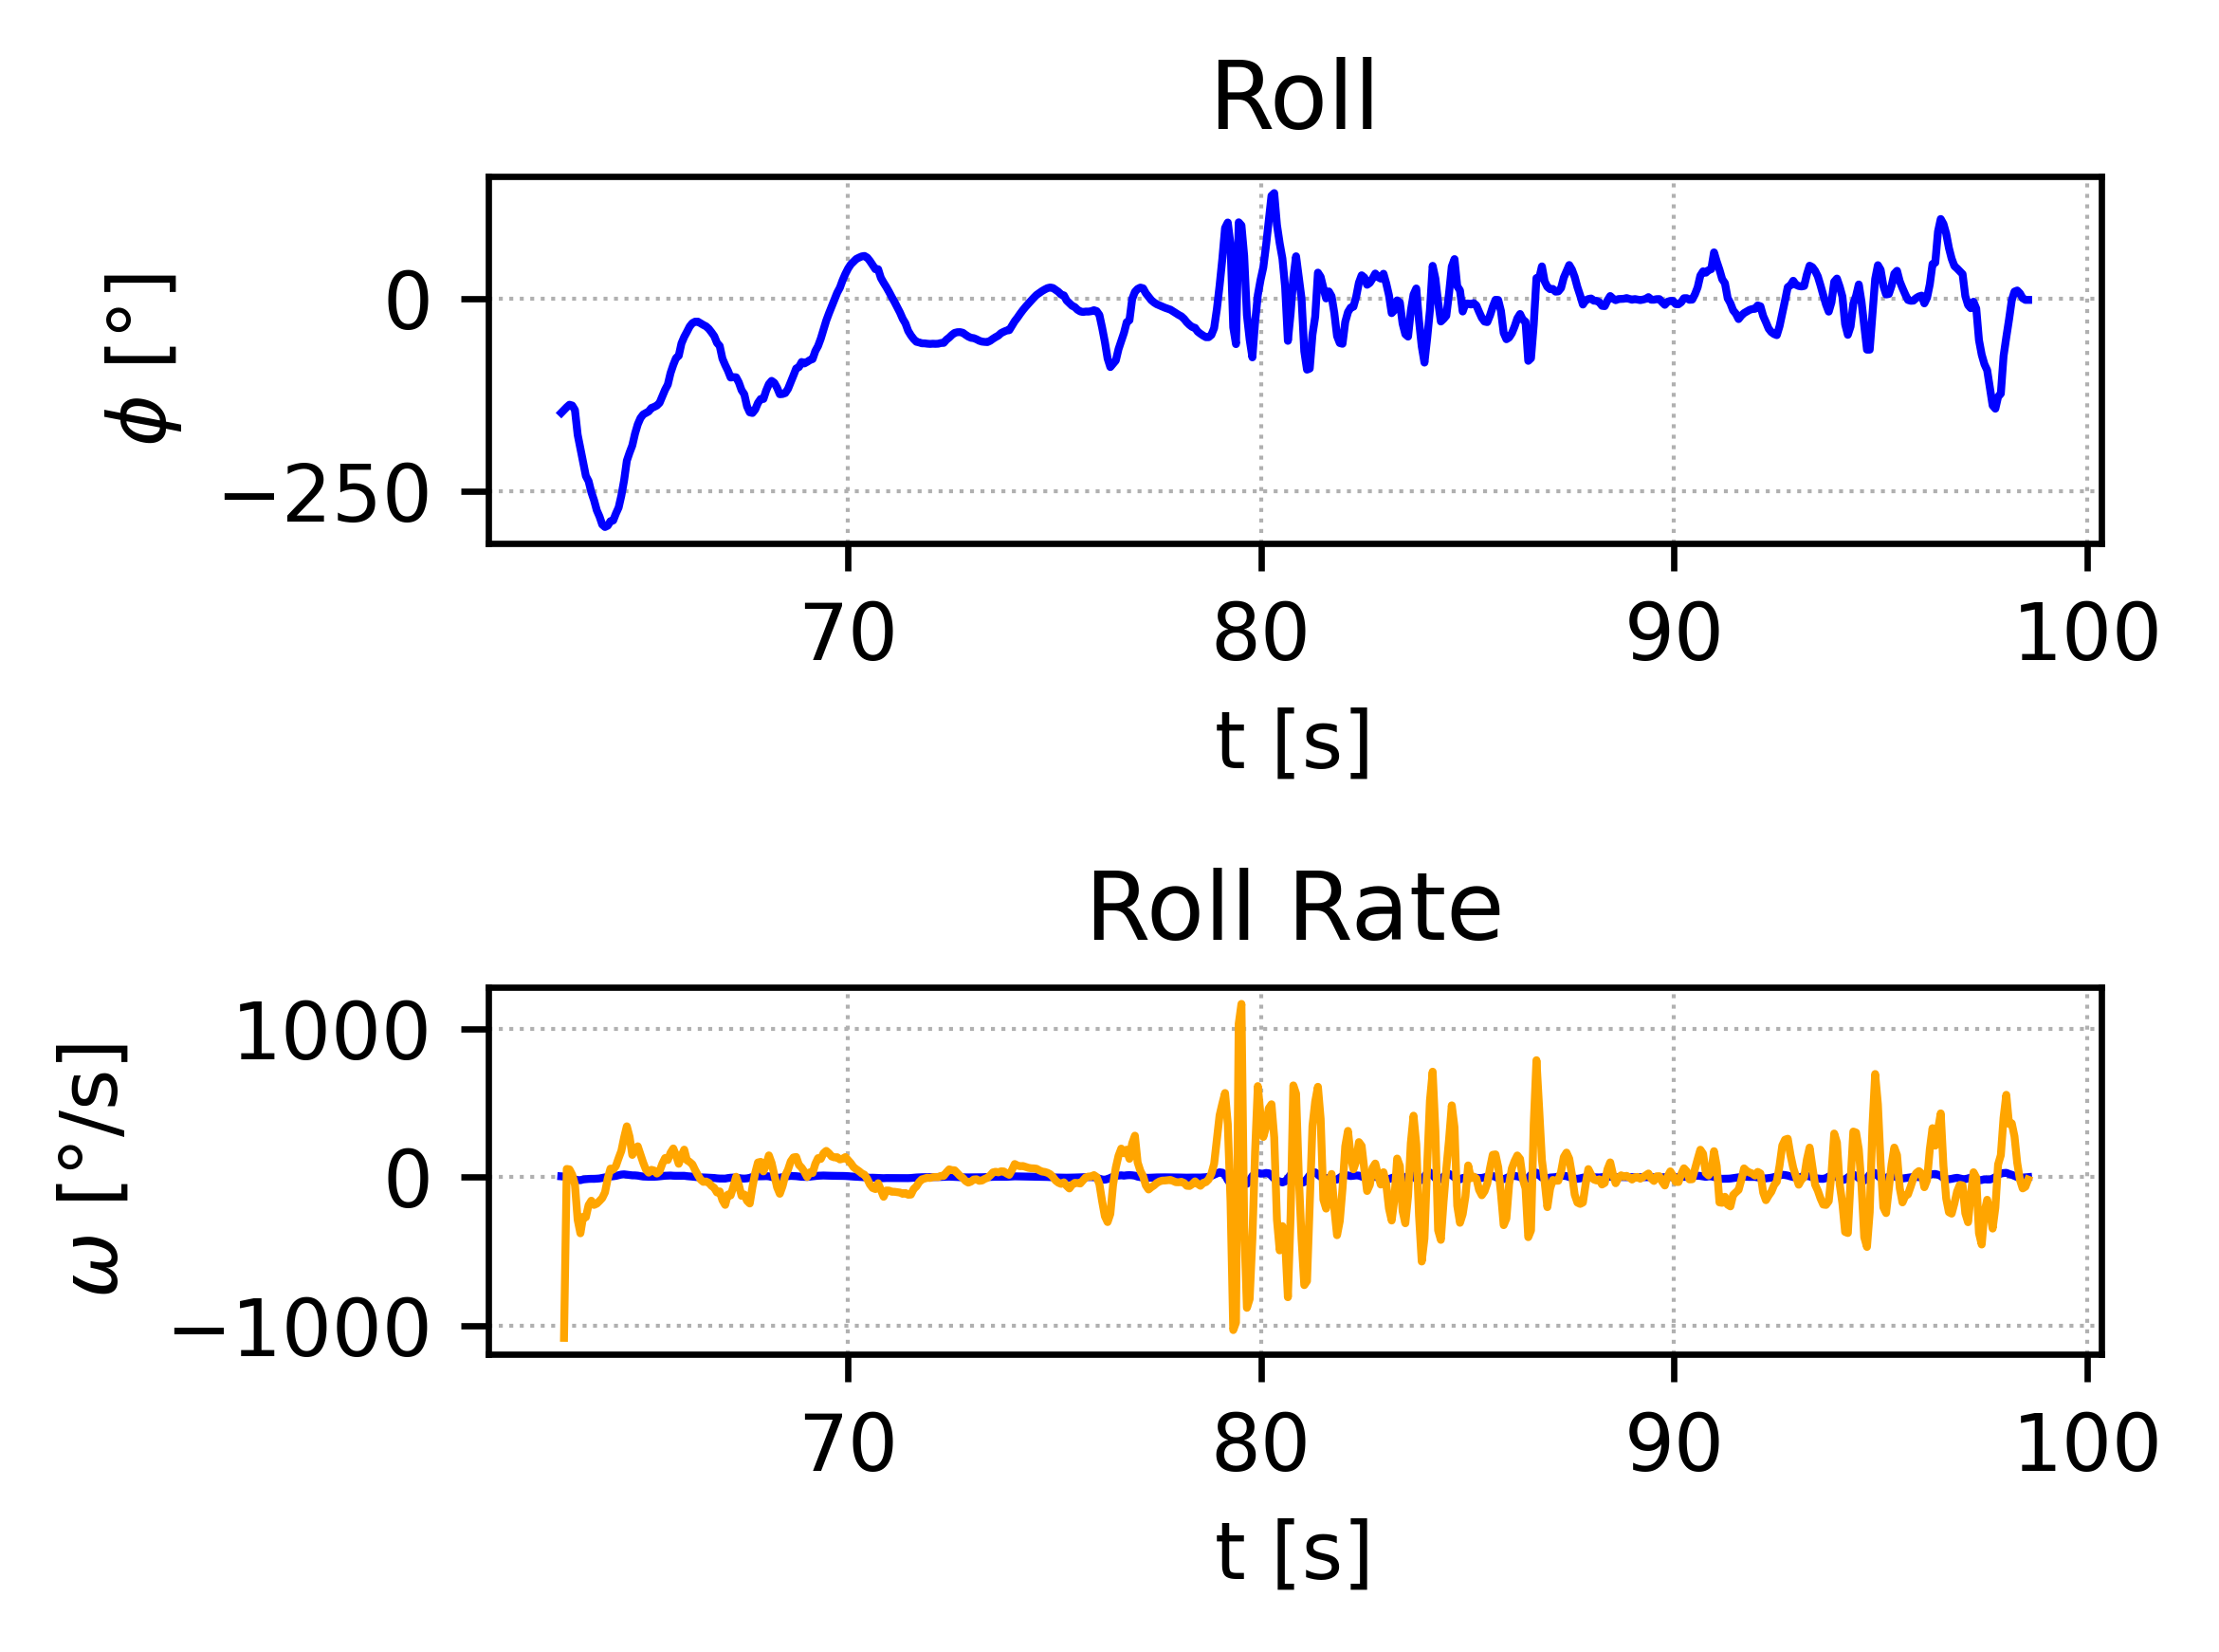

In [24]:
df = pd.read_csv('FT1_primary.csv')
t_old = df.iloc[2450:,4].to_numpy()
roll = df.iloc[2450:,19].to_numpy()
t = np.linspace(t_old[0], t_old[-1], len(t_old))
N = len(t)
dt = np.diff(t)[0]
roll = np.interp(t, t_old, roll)

# Sav-Gol derivative
roll_rate = savgol_filter(roll, window_length=5, polyorder=2, deriv=1)
roll_rate_num = [(roll[k+1]-roll[k-1])/(2*dt) for k in range(0,len(roll)-1)]

fig, axs = plt.subplots(2,1,dpi=300,figsize=(4,3))
# roll
axs[0].plot(t, roll, lw=1, c='blue')
axs[0].grid(lw=0.5, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi$ [$\degree$]')
axs[0].set_title('Roll')
# roll rate
axs[1].plot(t, roll_rate, lw=1, c='blue')
axs[1].plot(t[1:], roll_rate_num, lw=1, c='orange')
axs[1].grid(lw=0.5, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\omega$ [$\degree$/s]')
axs[1].set_title('Roll Rate')
plt.tight_layout()


### Gyroscope Specs

**Noise density ($\degree/s/\sqrt{Hz}$)**

How much noise per square root of bandwidth. Represents how much the angular rate will vary.

**Bandwidth (Hz)**

Highest frequency motion that the gyro passes through. Used to sort of smooth out the incoming data a little more. Larger bandwidth means more noise

**Bias stability ($\degree/hr$)**

How consistent the bias stays over time. Affects the white noise added to the bias term.

**Range ($\degree/s$)**

Maximum angular velocity it can detect before clipping 

**Resolution ($\degree/s$)**

Minimum detectable change in angular velocity. 


In [ ]:
# Measurement noise
noise_density = 0.0035 # deg/s/Hz^0.5
bandwidth = 265 # Hz
sig_omega = noise_density * np.sqrt(bandwidth)

# Process Noise
# bias
bias_stability = 5 # deg/Hr
bias_stability /= 3600 # deg/s
sig_bias = bias_stability
q_b = sig_bias**2 / 3600
Q_b = q_b * dt
# omega
sig_omega_rw = 3 # deg/s^2 for now
Q_omega = sig_omega**2 * dt 

Q = np.array([[0, 0,      0],
              [0, Q_omega,0],
              [0, 0,      q_b]]) # process noise
R = sig_omega**2 # (deg/s)^2 : Measurement noise (just omega)
x0 = (0, roll_rate[0], 0)
sig_phi = 20
P0 = np.array([[sig_phi**2, 0, 0],
               [0, sig_omega**2, 0],
               [0, 0, sig_bias**2]])


In [5]:
filter = KF(dt, x0, P0, Q, R)

states = []
covs = []
innovations = []
innovation_variances = []

for k in range(1, len(t)):
    # measurement
    z = np.array([[0], [roll_rate[k]], [0]])    
    y, S = filter.update(z)
    x_hat, P_hat = filter.predict()
    states.append(x_hat)
    covs.append(P_hat)
    innovations.append(y)
    innovation_variances.append(S)
states = np.array(states)
covs = np.array(covs)
innovations = np.array(innovations)
innovation_variances = np.array(innovation_variances)

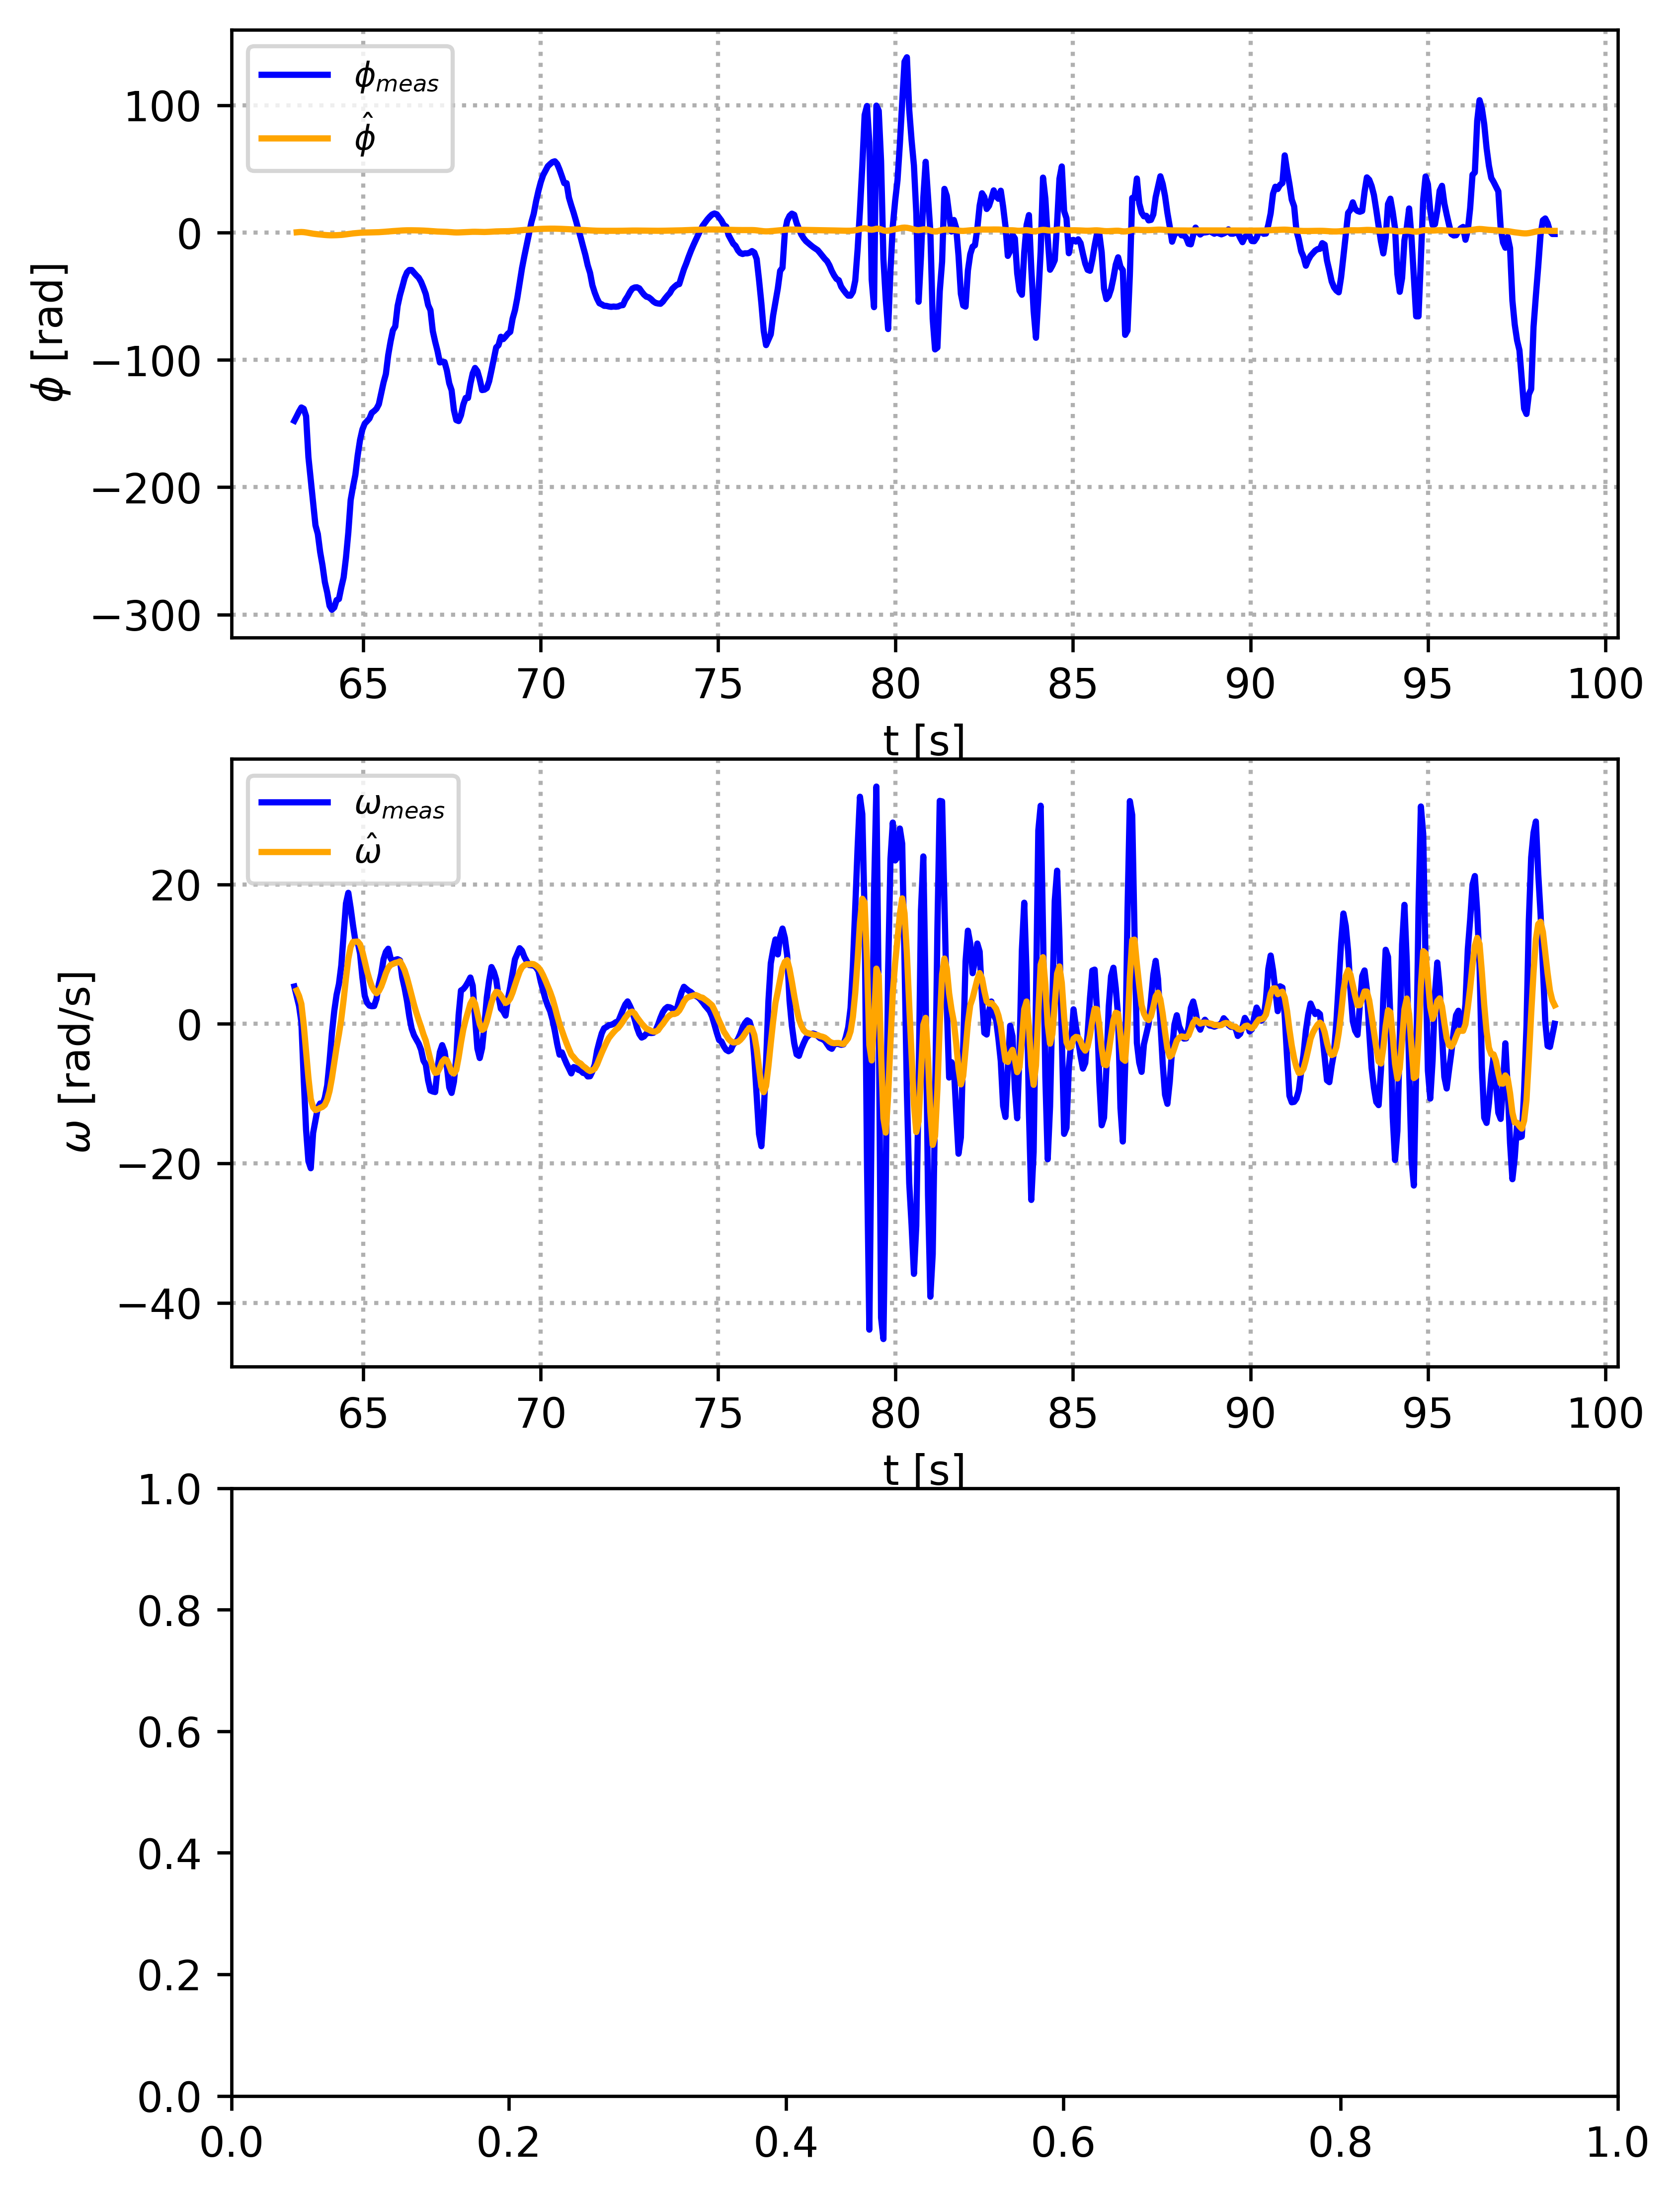

In [6]:
fig, axs = plt.subplots(3,1,dpi=300,figsize=(6,9))

# phi
phi_hats = states[:,0].flatten()
axs[0].plot(t, roll, c='blue', label=r'$\phi_{meas}$')
axs[0].plot(t[1:], phi_hats, c='orange', label=r'$\hat{\phi}$')
axs[0].grid(lw=1, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi$ [rad]')
axs[0].legend(fontsize=8)

# omega
omega_hats = states[:,1].flatten()
axs[1].plot(t, roll_rate, c='blue', label=r'$\omega_{meas}$')
axs[1].plot(t[1:], omega_hats, c='orange', label=r'$\hat{\omega}$')
#axs[1].set_ylim(-1000,1000)
axs[1].grid(lw=1, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\omega$ [rad/s]')
axs[1].legend(fontsize=8)

# # alpha
# alpha_hats = estimates_log[2:,2].flatten()
# axs[2].plot(t[2:], alpha, c='blue', label=r'$\alpha_{meas}$')
# axs[2].plot(t[2:], alpha_hats, c='orange', label=r'$\hat{\alpha}$')
# axs[2].set_ylim(-1000,1000)
# axs[2].grid(lw=1, ls=':')
# axs[2].set_xlabel('t [s]')
# axs[2].set_ylabel(r'$\alpha$ [rad/s^2]')
# axs[2].legend(fontsize=8);

### Simulate

In [143]:
# Measurement noise
noise_density = 0.0035 # deg/s/Hz^0.5
bandwidth = 265 # Hz
sig_omega = noise_density * np.sqrt(bandwidth)

# Process Noise
# bias
bias_stability = 5 # deg/Hr
bias_stability /= 3600 # deg/s
sig_bias = bias_stability
q_b = sig_bias**2 #/ 3600
Q_b = q_b * dt
# omega
sig_omega_rw = 3 # deg/s^2 for now
Q_omega = sig_omega**2# * dt 

Q = np.array([[0, 0,      0],
              [0, Q_omega,0],
              [0, 0,      Q_b]])#Q_b]]) # process noise
R = sig_omega**2 # (deg/s)^2 Measurement noise (just omega)
x0 = (0,0,0)#(0, roll_rate[0], 0)
sig_phi = 20
# P0 = np.array([[0.1, 0, 0],
#                [0, sig_omega**2, 0],
#                [0, 0, sig_bias**2]])
P0 = np.array([[50, 0, 0],
               [0, 50, 0],
               [0, 0, 50]])


In [124]:
x0_sim = (0,0,0)
rng = np.random.default_rng(3)
bias_rw_std = sig_bias / np.sqrt(t[-1] - t[0])
truth = simulate_roll_truth(t=t, x0=x0_sim, sigma_gyro=sig_omega, bias_rw_std=bias_rw_std,
                            tau_dist_std=0.02, tau_dist_tau=0.15, Kp=0.0, Kd=0.0, rng=rng)
phi, omega, b, tau_dist, z_gyro = truth

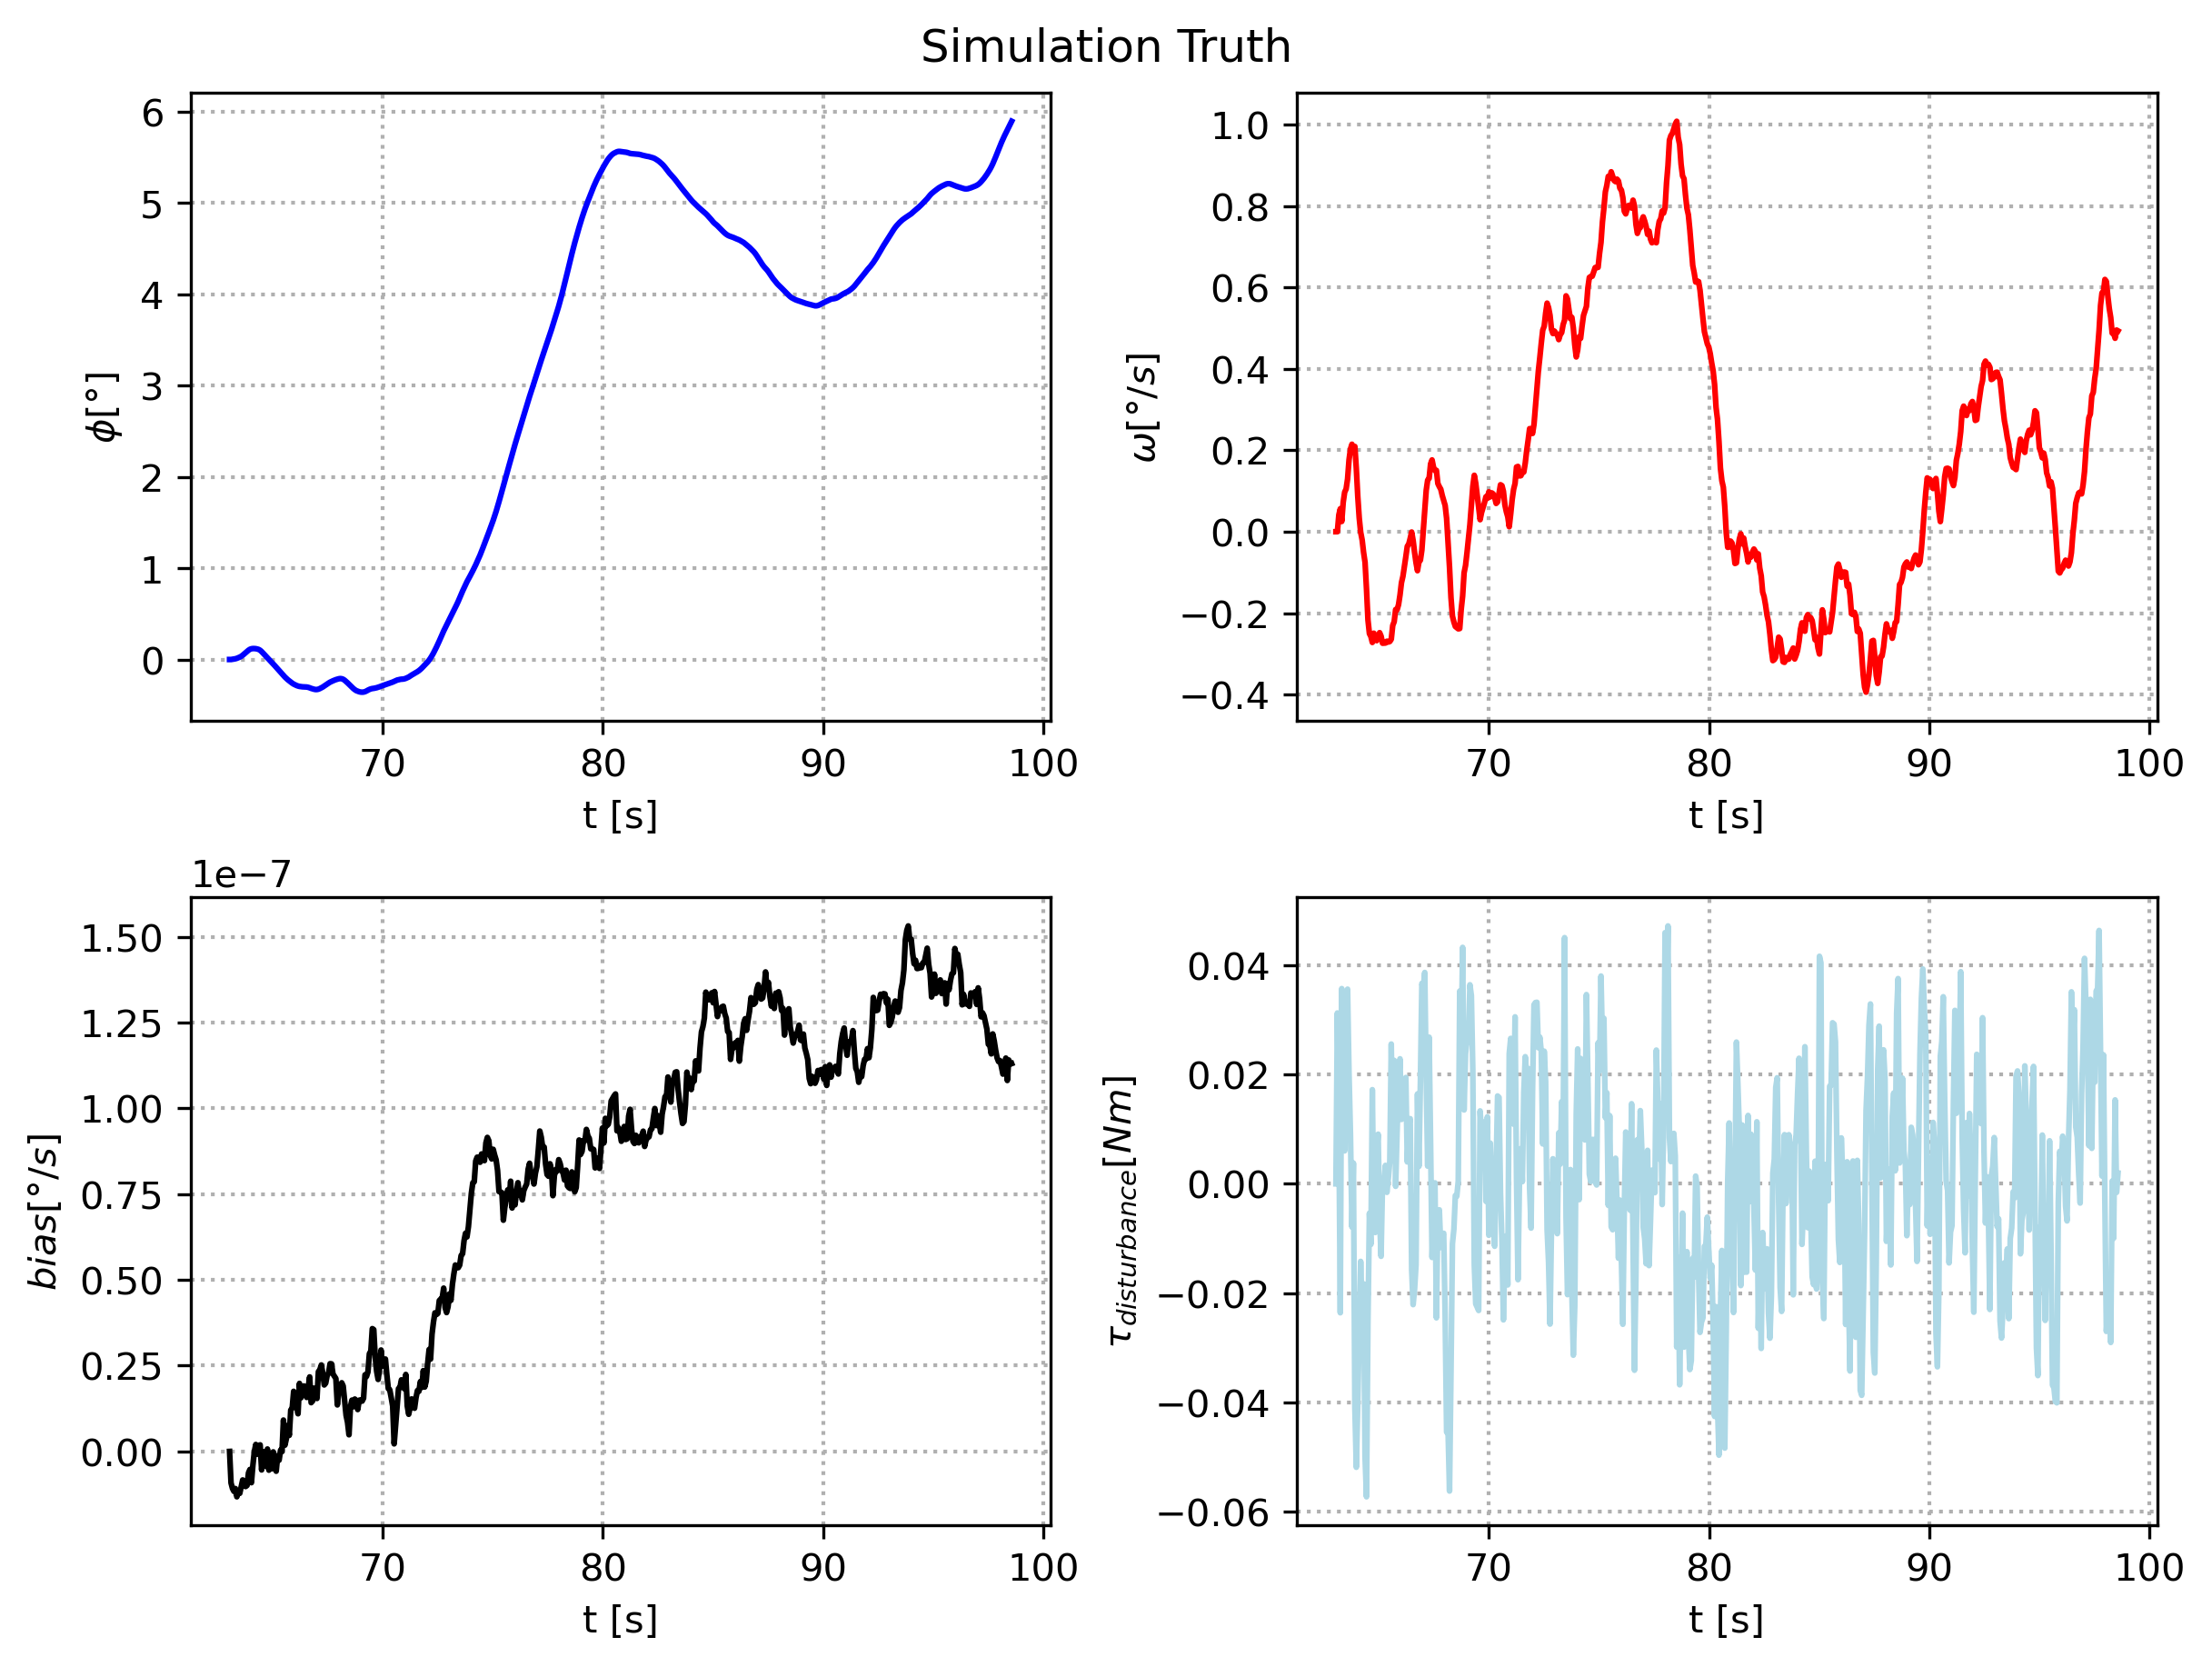

In [125]:
fig, axs = plt.subplots(2,2,dpi=150,figsize=(8,6),constrained_layout=True)

fig.suptitle('Simulation Truth')
axs[0,0].plot(t, phi, c='blue', label='Truth')
axs[0,0].grid(lw=1, ls=':')
axs[0,0].set_xlabel('t [s]')
axs[0,0].set_ylabel(r'$\phi [\degree]$')
axs[0,1].plot(t, omega, c='red', label='Truth')
axs[0,1].grid(lw=1, ls=':')
axs[0,1].set_xlabel('t [s]')
axs[0,1].set_ylabel(r'$\omega [\degree/s]$')
axs[1,0].plot(t, b, c='black', label='Truth')
axs[1,0].grid(lw=1, ls=':')
axs[1,0].set_xlabel('t [s]')
axs[1,0].set_ylabel(r'$bias [\degree/s]$')
axs[1,1].plot(t, tau_dist, c='lightblue')
axs[1,1].grid(lw=1, ls=':')
axs[1,1].set_xlabel('t [s]')
axs[1,1].set_ylabel(r'$\tau_{disturbance} [N m]$');

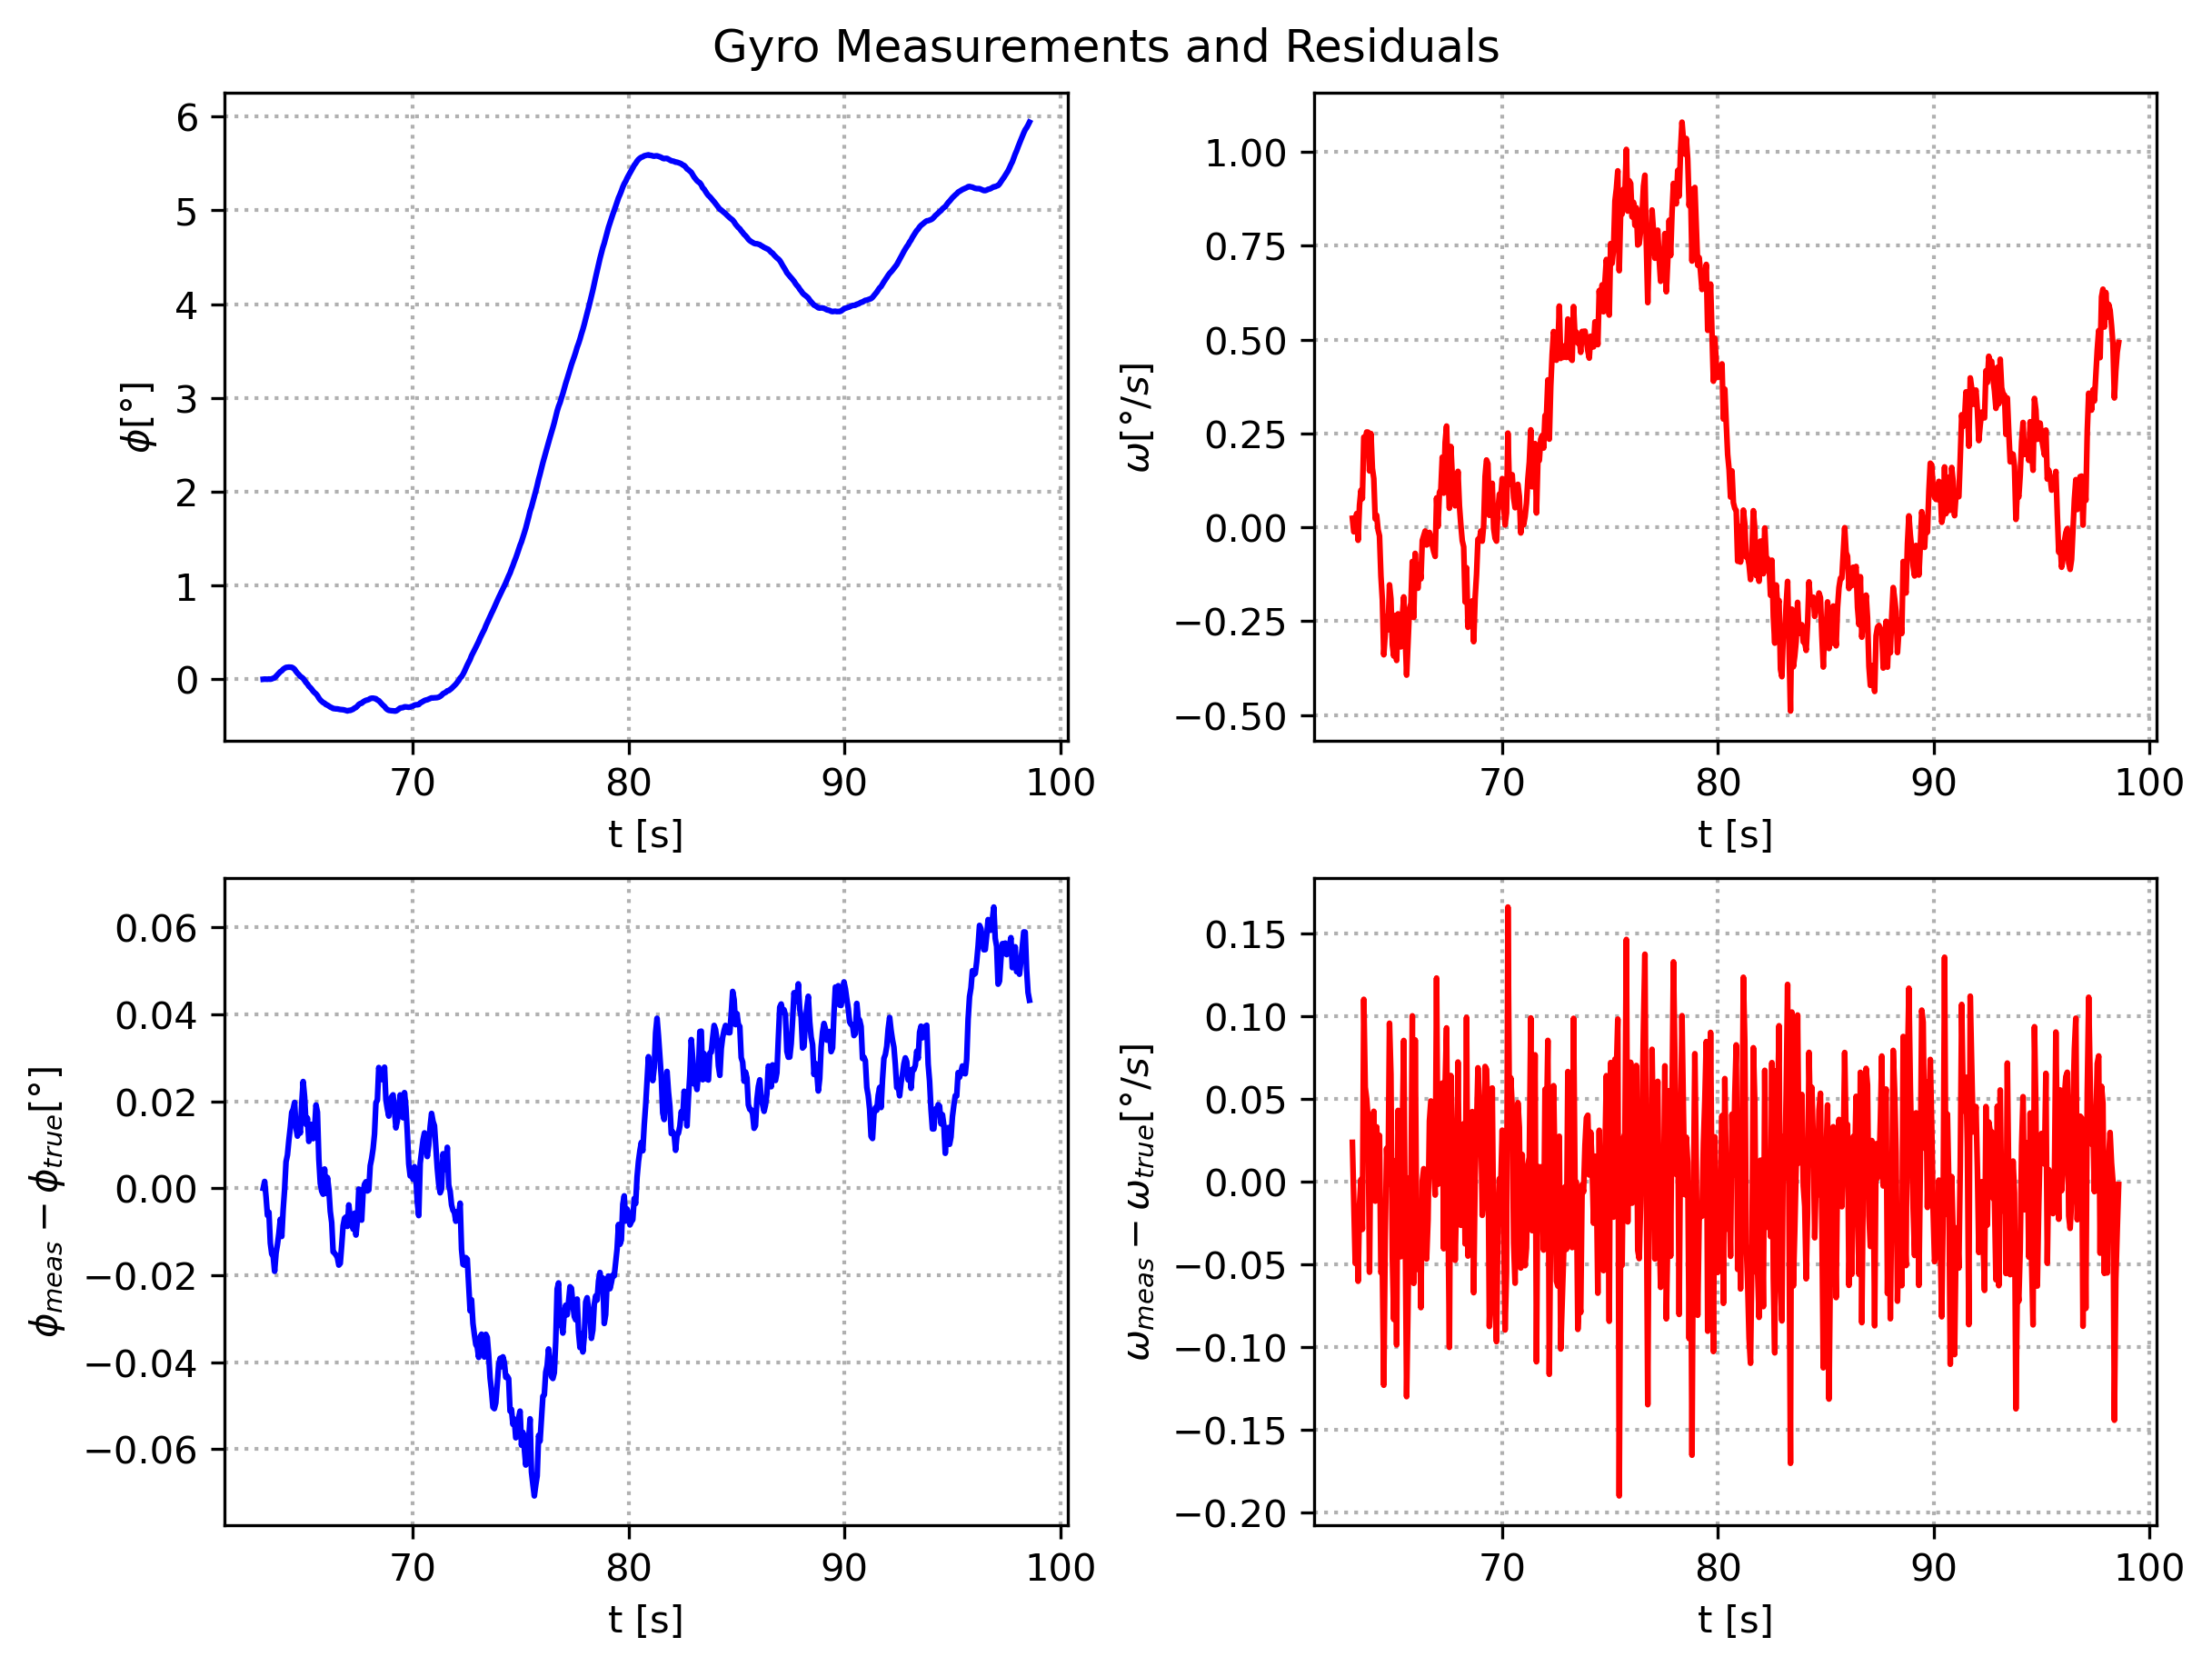

In [83]:
z_angle = np.empty(len(t))
z_angle[0] = x0[0]
for k in range(len(t)-1):
    z_angle[k+1] = z_angle[k] + z_gyro[k] * dt

fig, axs = plt.subplots(2,2,dpi=150,figsize=(8,6),constrained_layout=True)

fig.suptitle('Gyro Measurements and Residuals')
axs[0,0].plot(t, z_angle, c='blue', label='')
axs[0,0].grid(lw=1, ls=':')
axs[0,0].set_xlabel('t [s]')
axs[0,0].set_ylabel(r'$\phi [\degree]$')
axs[0,1].plot(t, z_gyro, c='red', label='')
axs[0,1].grid(lw=1, ls=':')
axs[0,1].set_xlabel('t [s]')
axs[0,1].set_ylabel(r'$\omega [\degree/s]$')
axs[1,0].plot(t, z_angle - phi, c='blue', label='')
axs[1,0].grid(lw=1, ls=':')
axs[1,0].set_xlabel('t [s]')
axs[1,0].set_ylabel(r'$\phi_{meas} - \phi_{true} [\degree]$')
axs[1,1].plot(t, z_gyro - omega, c='red', label='')
axs[1,1].grid(lw=1, ls=':')
axs[1,1].set_xlabel('t [s]')
axs[1,1].set_ylabel(r'$\omega_{meas} - \omega_{true} [\degree/s]$');

In [144]:
filter = KF(dt, x0, P0, Q, R)

states = np.zeros((N, 3, 1))
covs = np.zeros((N, 3, 3))
innovations = np.zeros((N, 3, 1))
innovation_variances = np.zeros((N, 3, 3))

for k in range(N):
    # measurement
    z = np.array([[0], [z_gyro[k]], [0]])    
    y, S = filter.update(z)
    x_hat, P_hat = filter.predict()
    states[k] = x_hat
    covs[k] = P_hat
    innovations[k] = y
    innovation_variances[k] = S

[[ 50.10932183   1.6532194   -1.65311207]
 [  1.6532194   25.00405779 -24.99918846]
 [ -1.65311207 -24.99918846  25.00081166]]
[[ 50.43728258   3.30643881  -3.3062957 ]
 [  3.30643881  25.00486941 -25.00000005]
 [ -3.3062957  -25.00000005  25.00054125]]
[[ 50.98388446   4.95966492  -4.95949051]
 [  4.95966492  25.0053767  -25.00030447]
 [ -4.95949051 -25.00030447  25.00050754]]
[[ 51.7491276    6.61288275  -6.61268853]
 [  6.61288275  25.00560384 -25.00042534]
 [ -6.61268853 -25.00042534  25.00050283]]
[[ 52.7330118    8.26609219  -8.26588729]
 [  8.26609219  25.005696   -25.00047254]
 [ -8.26588729 -25.00047254  25.00050225]]
[[ 53.93553699   9.91929638  -9.91908619]
 [  9.91929638  25.00573208 -25.0004908 ]
 [ -9.91908619 -25.0004908   25.00050227]]
[[ 55.35670313  11.5724978  -11.57228513]
 [ 11.5724978   25.00574607 -25.00049787]
 [-11.57228513 -25.00049787  25.00050239]]
[[ 56.99651022  13.22569788 -13.22548409]
 [ 13.22569788  25.0057515  -25.00050066]
 [-13.22548409 -25.00050066

In [160]:
np.transpose(innovations, 1)

ValueError: axes don't match array

In [114]:
filter = KF(dt, x0, P0, Q, R)
z = np.array([[0], [z_gyro[0]], [0]]) 
filter.update(z)

(array([[-1.        ],
        [-0.97617845],
        [-1.        ]]),
 array([[60.00324625]]))

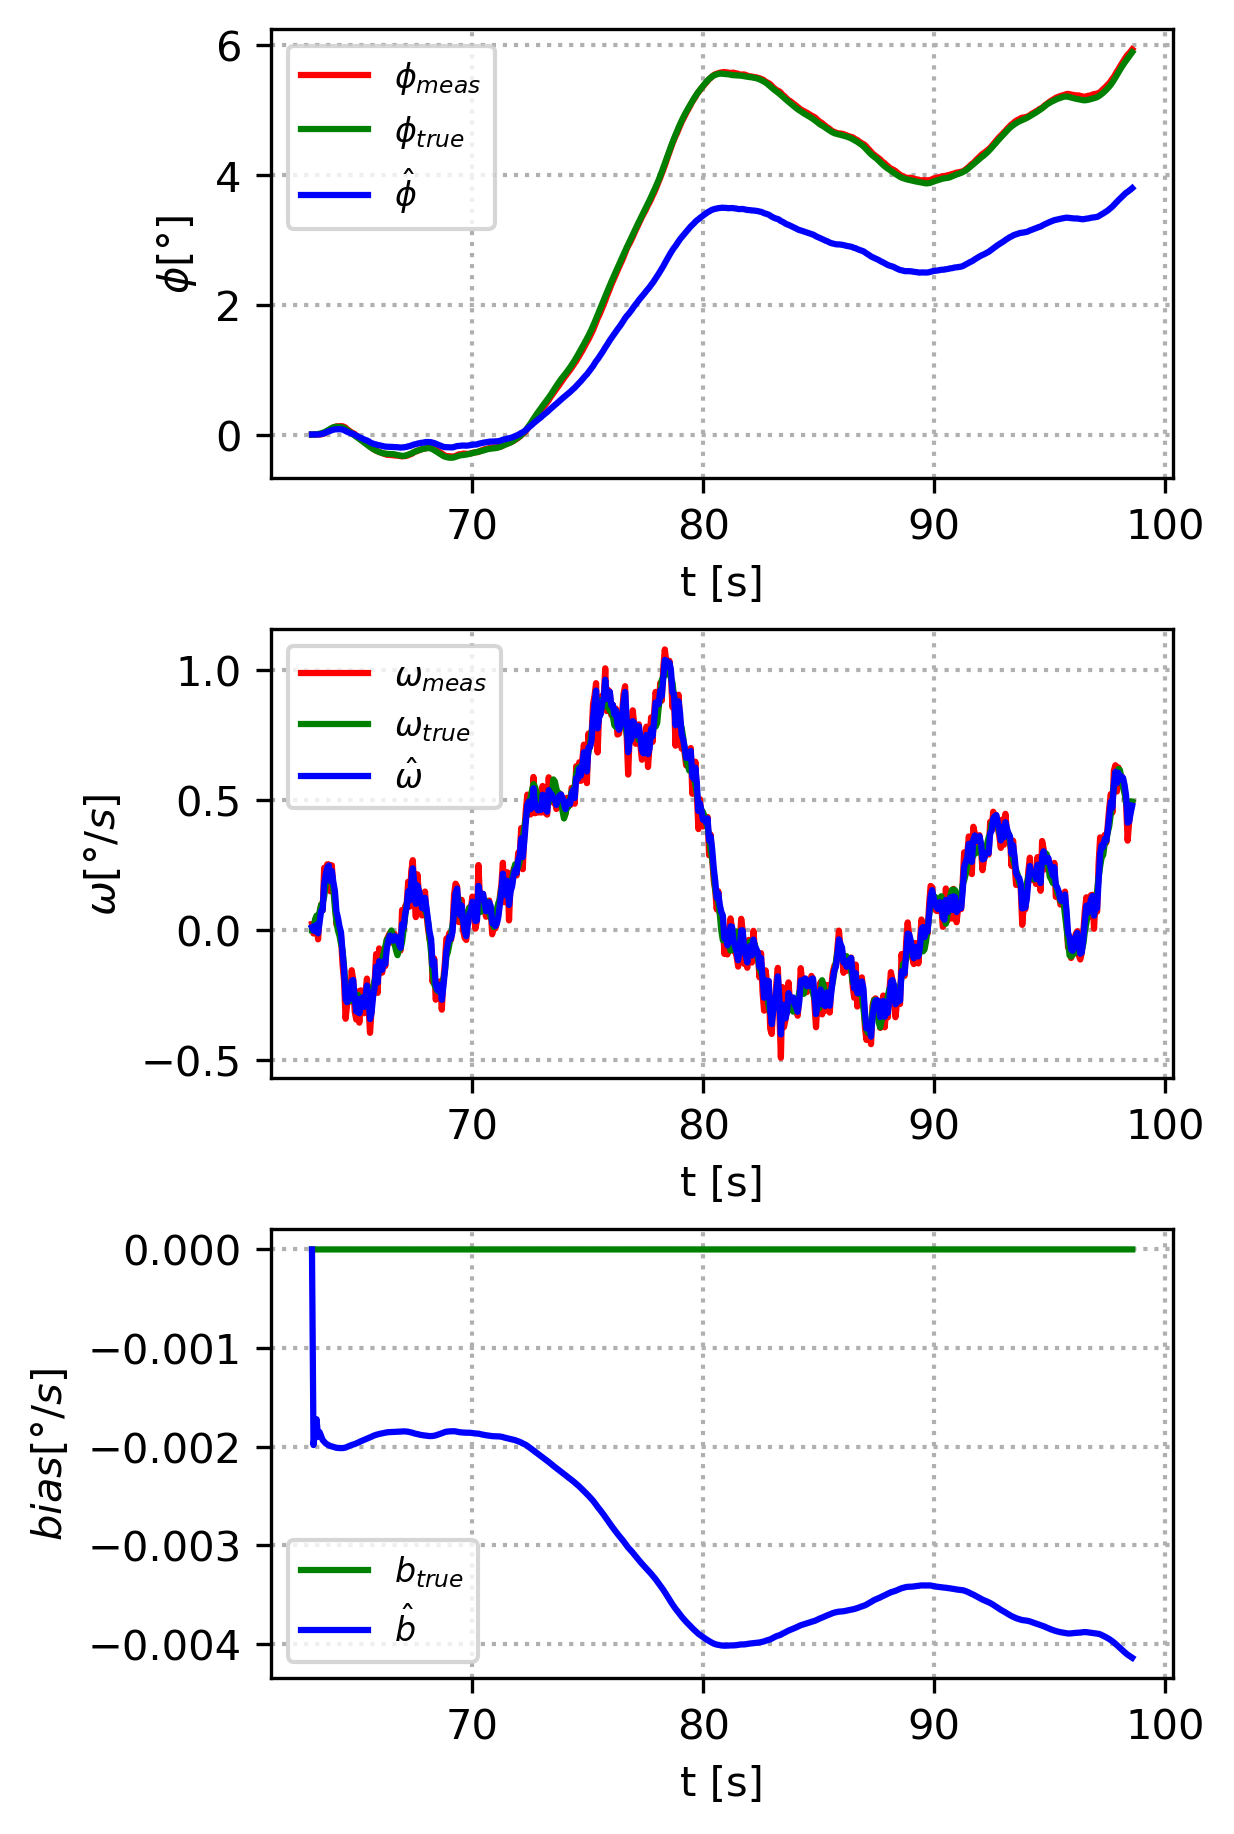

In [145]:
fig, axs = plt.subplots(3,1,dpi=150,figsize=(4,6),constrained_layout=True)

# phi
phi_hats = states[:,0].flatten()
axs[0].plot(t, z_angle, c='red', label=r'$\phi_{meas}$')
axs[0].plot(t, phi, c='green', label=r'$\phi_{true}$')
axs[0].plot(t, phi_hats, c='blue', label=r'$\hat{\phi}$')
axs[0].grid(lw=1, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi [\degree]$')
axs[0].legend(fontsize=8)
omega_hats = states[:,1].flatten()
axs[1].plot(t, z_gyro, c='red', label=r'$\omega_{meas}$')
axs[1].plot(t, omega, c='green', label=r'$\omega_{true}$')
axs[1].plot(t, omega_hats, c='blue', label=r'$\hat{\omega}$')
axs[1].grid(lw=1, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\omega [\degree/s]$')
axs[1].legend(fontsize=8)
bias_hats = states[:,2].flatten()
#axs[1].plot(t, z_gyro, c='red', label=r'$\b_{meas}$')
axs[2].plot(t, b, c='green', label=r'$b_{true}$')
axs[2].plot(t, bias_hats, c='blue', label=r'$\hat{b}$')
axs[2].grid(lw=1, ls=':')
axs[2].set_xlabel('t [s]')
axs[2].set_ylabel(r'$bias [\degree/s]$')
axs[2].legend(fontsize=8);

In [142]:
innovations

array([[[ 0.        ],
        [ 0.02382155],
        [ 0.        ]],

       [[-0.01191013],
        [-0.02419397],
        [-0.01191013]],

       [[ 0.00217138],
        [-0.00580301],
        [ 0.00217138]],

       ...,

       [[-0.40853431],
        [ 0.00788974],
        [-0.40853431]],

       [[-0.41325837],
        [ 0.05324779],
        [-0.41325837]],

       [[-0.44600146],
        [ 0.04581705],
        [-0.44600146]]])

In [13]:
dt = 1 / fs
N = int(np.round(T * fs)) + 1 # num samples
t = np.linspace(0.0, T, N)

sigma_gyro = gyro_noise_density * np.sqrt(max(gyro_bandwidth, 0.0))
    z_gyro = np.zeros(N)

IndentationError: unexpected indent (164878039.py, line 6)

In [ ]:
rng = np.random.default_rng(3)
bbb = 0.5
dt = 0.05
print(bbb * np.sqrt(dt) * rng.standard_normal())
print(rng.normal(0, bbb**2 * dt))

0.22818169459982063
-0.031945812891427276


In [ ]:
import numpy as np

def simulate_roll_truth(
    T=20.0,              # total seconds
    fs=200.0,            # Hz sample rate
    phi0=0.0,            # initial roll angle [rad]
    omega0=0.0,          # initial roll rate  [rad/s]
    b0=0.0,              # initial gyro bias  [rad/s]
    I=0.05,              # roll moment of inertia [kg*m^2] (rough guess; tune later)
    # Disturbance + control (both optional)
    tau_dist_std=0.02,   # disturbance torque std [N*m]
    tau_dist_tau=0.15,   # disturbance torque correlation time [s] (Gauss-Markov)
    Kp=0.0,              # control gain on angle  [N*m/rad]  (0 disables control)
    Kd=0.0,              # control gain on rate   [N*m/(rad/s)]
    tau_max=np.inf,      # control torque saturation [N*m]
    # Gyro measurement model
    gyro_noise_density=0.0,  # [rad/s/√Hz], e.g. deg/s/√Hz * pi/180
    gyro_bandwidth=100.0,    # [Hz] effective bandwidth for rate noise shaping
    # Bias drift model (random walk)
    bias_rw_std_per_s=np.deg2rad(0.02/3600.0),  # [rad/s]/sqrt(s), e.g. 0.02 deg/hr/sqrt(s) -> tweak
    seed=0
):
    """
    Minimal roll "truth" simulation + gyro measurement.

    Truth states:
      phi[k]   roll angle [rad]
      omega[k] roll rate  [rad/s]
      b[k]     gyro bias  [rad/s]

    Dynamics:
      omega_dot = (tau_ctrl + tau_dist) / I
      phi_dot   = omega
      b_{k+1}   = b_k + w_b,  where w_b ~ N(0, (bias_rw_std_per_s^2)*dt)

    Measurement:
      z_gyro = omega + b + v, where v is white noise derived from noise density.
    """
    rng = np.random.default_rng(seed)

    dt = 1.0 / fs
    N = int(np.round(T * fs)) + 1
    t = np.linspace(0.0, T, N)

    phi = np.zeros(N)
    omega = np.zeros(N)
    b = np.zeros(N)

    phi[0] = phi0
    omega[0] = omega0
    b[0] = b0

    # Correlated disturbance torque: Gauss-Markov (Ornstein–Uhlenbeck)
    tau_dist = np.zeros(N)
    if tau_dist_tau <= 0:
        tau_dist_tau = 1e-6
    a = np.exp(-dt / tau_dist_tau)
    # Choose driving noise so stationary std is tau_dist_std
    q = tau_dist_std * np.sqrt(1 - a**2)

    # Gyro measurement noise std per sample from noise density and bandwidth
    # Approx: sigma ≈ nd * sqrt(BW)
    sigma_gyro = gyro_noise_density * np.sqrt(max(gyro_bandwidth, 0.0))
    z_gyro = np.zeros(N)

    # Helper: saturation
    def sat(x, lim):
        if not np.isfinite(lim):
            return x
        return np.clip(x, -lim, lim)

    for k in range(N - 1):
        # Disturbance torque update
        tau_dist[k+1] = a * tau_dist[k] + q * rng.standard_normal()

        # Simple PD control to drive phi -> 0 (optional)
        tau_ctrl = sat(-Kp * phi[k] - Kd * omega[k], tau_max)

        # Truth dynamics
        alpha = (tau_ctrl + tau_dist[k]) / I  # rad/s^2

        # Integrate (semi-implicit / symplectic-ish)
        omega[k+1] = omega[k] + alpha * dt
        phi[k+1] = phi[k] + omega[k+1] * dt  # use updated omega for a bit more stability

        # Bias random walk
        b[k+1] = b[k] + bias_rw_std_per_s * np.sqrt(dt) * rng.standard_normal()

        # Gyro measurement at time k (can also choose k+1)
        z_gyro[k] = omega[k] + b[k] + sigma_gyro * rng.standard_normal()

    # last measurement
    z_gyro[-1] = omega[-1] + b[-1] + sigma_gyro * rng.standard_normal()

    return {
        "t": t,
        "phi": phi,
        "omega": omega,
        "bias": b,
        "tau_dist": tau_dist,
        "z_gyro": z_gyro,
        "dt": dt,
        "fs": fs,
        "meta": {
            "sigma_gyro_per_sample": sigma_gyro,
            "gyro_noise_density": gyro_noise_density,
            "gyro_bandwidth": gyro_bandwidth,
            "bias_rw_std_per_s": bias_rw_std_per_s,
        },
    }


if __name__ == "__main__":
    # Example usage (units in radians):
    # Convert your spec example: 0.0035 deg/s/√Hz -> rad/s/√Hz
    nd = np.deg2rad(0.0035)

    sim = simulate_roll_truth(
        T=30.0,
        fs=200.0,
        phi0=np.deg2rad(10.0),
        omega0=0.0,
        b0=np.deg2rad(0.2),          # constant-ish offset to start
        I=0.05,
        tau_dist_std=0.03,
        tau_dist_tau=0.2,
        Kp=0.05,                      # try 0.0 if you want open-loop only
        Kd=0.02,
        tau_max=0.2,
        gyro_noise_density=nd,
        gyro_bandwidth=265.0,
        bias_rw_std_per_s=np.deg2rad(0.05/3600.0),  # tweak: bias wander speed
        seed=1
    )

    # Quick sanity prints
    print("dt:", sim["dt"])
    print("gyro sigma per sample [deg/s]:", np.rad2deg(sim["meta"]["sigma_gyro_per_sample"]))
    print("final angle [deg]:", np.rad2deg(sim["phi"][-1]))
    print("final bias [deg/s]:", np.rad2deg(sim["bias"][-1]))


dt: 0.005
gyro sigma per sample [deg/s]: 0.05697587208634897
final angle [deg]: 1.6393371145942492
final bias [deg/s]: 0.1999049009550954


In [ ]:
import numpy as np

def simulate_measurements_from_truth(
    t,
    phi_true,
    omega_true,
    bias_true=None,              # if you have truth bias; else set None to generate one
    gyro_noise_density=0.0,      # [rad/s/√Hz]
    gyro_bandwidth=100.0,        # [Hz]
    gyro_rate_bias0=0.0,         # [rad/s] used only if bias_true is None
    bias_rw_std_per_s=0.0,       # [rad/s]/sqrt(s) used only if bias_true is None
    # realism knobs
    rate_saturation=np.inf,      # [rad/s]
    rate_lsb=None,               # [rad/s] quantization step; None disables quantization
    angle_wrap=None,             # None or "360" or "180"  (wrap output like some systems)
    dropout_prob=0.0,            # probability each sample is missing
    seed=0
):
    """
    Returns:
      z_rate:  simulated gyro rate measurement [rad/s]
      z_angle: simulated "gyro angle" measurement [rad] = integrated z_rate (incl bias+noise)
      bias:    bias used [rad/s]
      valid:   boolean mask (True = sample present)
    """
    rng = np.random.default_rng(seed)

    t = np.asarray(t)
    phi_true = np.asarray(phi_true)
    omega_true = np.asarray(omega_true)
    assert t.ndim == phi_true.ndim == omega_true.ndim == 1
    assert len(t) == len(phi_true) == len(omega_true)

    dt = np.median(np.diff(t))  # assumes ~uniform sampling
    N = len(t)

    # Bias: use provided truth bias, or synthesize one
    if bias_true is None:
        bias = np.empty(N, dtype=float)
        bias[0] = gyro_rate_bias0
        for k in range(N - 1):
            bias[k+1] = bias[k] + bias_rw_std_per_s * np.sqrt(dt) * rng.standard_normal()
    else:
        bias = np.asarray(bias_true)
        assert bias.shape == (N,)

    # Rate noise per sample from noise density and bandwidth
    # Practical approx: sigma ≈ nd * sqrt(BW)
    sigma_rate = gyro_noise_density * np.sqrt(max(gyro_bandwidth, 0.0))

    # Ideal rate measurement
    z_rate = omega_true + bias + sigma_rate * rng.standard_normal(N)

    # Saturation (clips like sensor range)
    if np.isfinite(rate_saturation):
        z_rate = np.clip(z_rate, -rate_saturation, rate_saturation)

    # Quantization (LSB)
    if rate_lsb is not None and rate_lsb > 0:
        z_rate = np.round(z_rate / rate_lsb) * rate_lsb

    # Dropouts
    if dropout_prob > 0:
        valid = rng.random(N) > dropout_prob
    else:
        valid = np.ones(N, dtype=bool)

    z_rate_obs = z_rate.copy()
    z_rate_obs[~valid] = np.nan

    # "Gyro angle" measurement: integrate the observed rate (carry forward through dropouts)
    z_angle = np.empty(N, dtype=float)
    z_angle[0] = phi_true[0]  # or 0.0 if you want arbitrary initial angle

    # If dropout, simplest is hold-last-rate at 0 or last good value
    last_rate = z_rate[0]
    for k in range(N - 1):
        if valid[k]:
            last_rate = z_rate[k]
        # integrate using last known rate
        z_angle[k+1] = z_angle[k] + last_rate * dt

    # Optional wrapping (common in logs)
    if angle_wrap == "360":
        z_angle = (z_angle % (2*np.pi))
    elif angle_wrap == "180":
        z_angle = (z_angle + np.pi) % (2*np.pi) - np.pi

    return {
        "z_rate": z_rate_obs,      # [rad/s], with NaNs for dropouts
        "z_angle": z_angle,        # [rad]
        "bias_used": bias,         # [rad/s]
        "valid": valid,            # bool mask
        "sigma_rate_per_sample": sigma_rate,
        "dt": dt,
    }


In [ ]:
# Example: build measurements from truth
nd = np.deg2rad(0.0035)  # 0.0035 deg/s/√Hz -> rad/s/√Hz

meas = simulate_measurements_from_truth(
    t=sim["t"],
    phi_true=sim["phi"],
    omega_true=sim["omega"],
    bias_true=sim["bias"],             # use truth bias from sim
    gyro_noise_density=nd,
    gyro_bandwidth=265.0,
    rate_saturation=np.deg2rad(2000),  # ±2000 deg/s
    rate_lsb=None,                     # set if you know sensor quantization
    angle_wrap="180",                  # mimic old logs if they wrap to ±180°
    dropout_prob=0.0,
    seed=42
)

z_rate  = meas["z_rate"]   # what you’d feed a KF that measures rate
z_angle = meas["z_angle"]  # what you’d have if your log only stores "gyro angle"


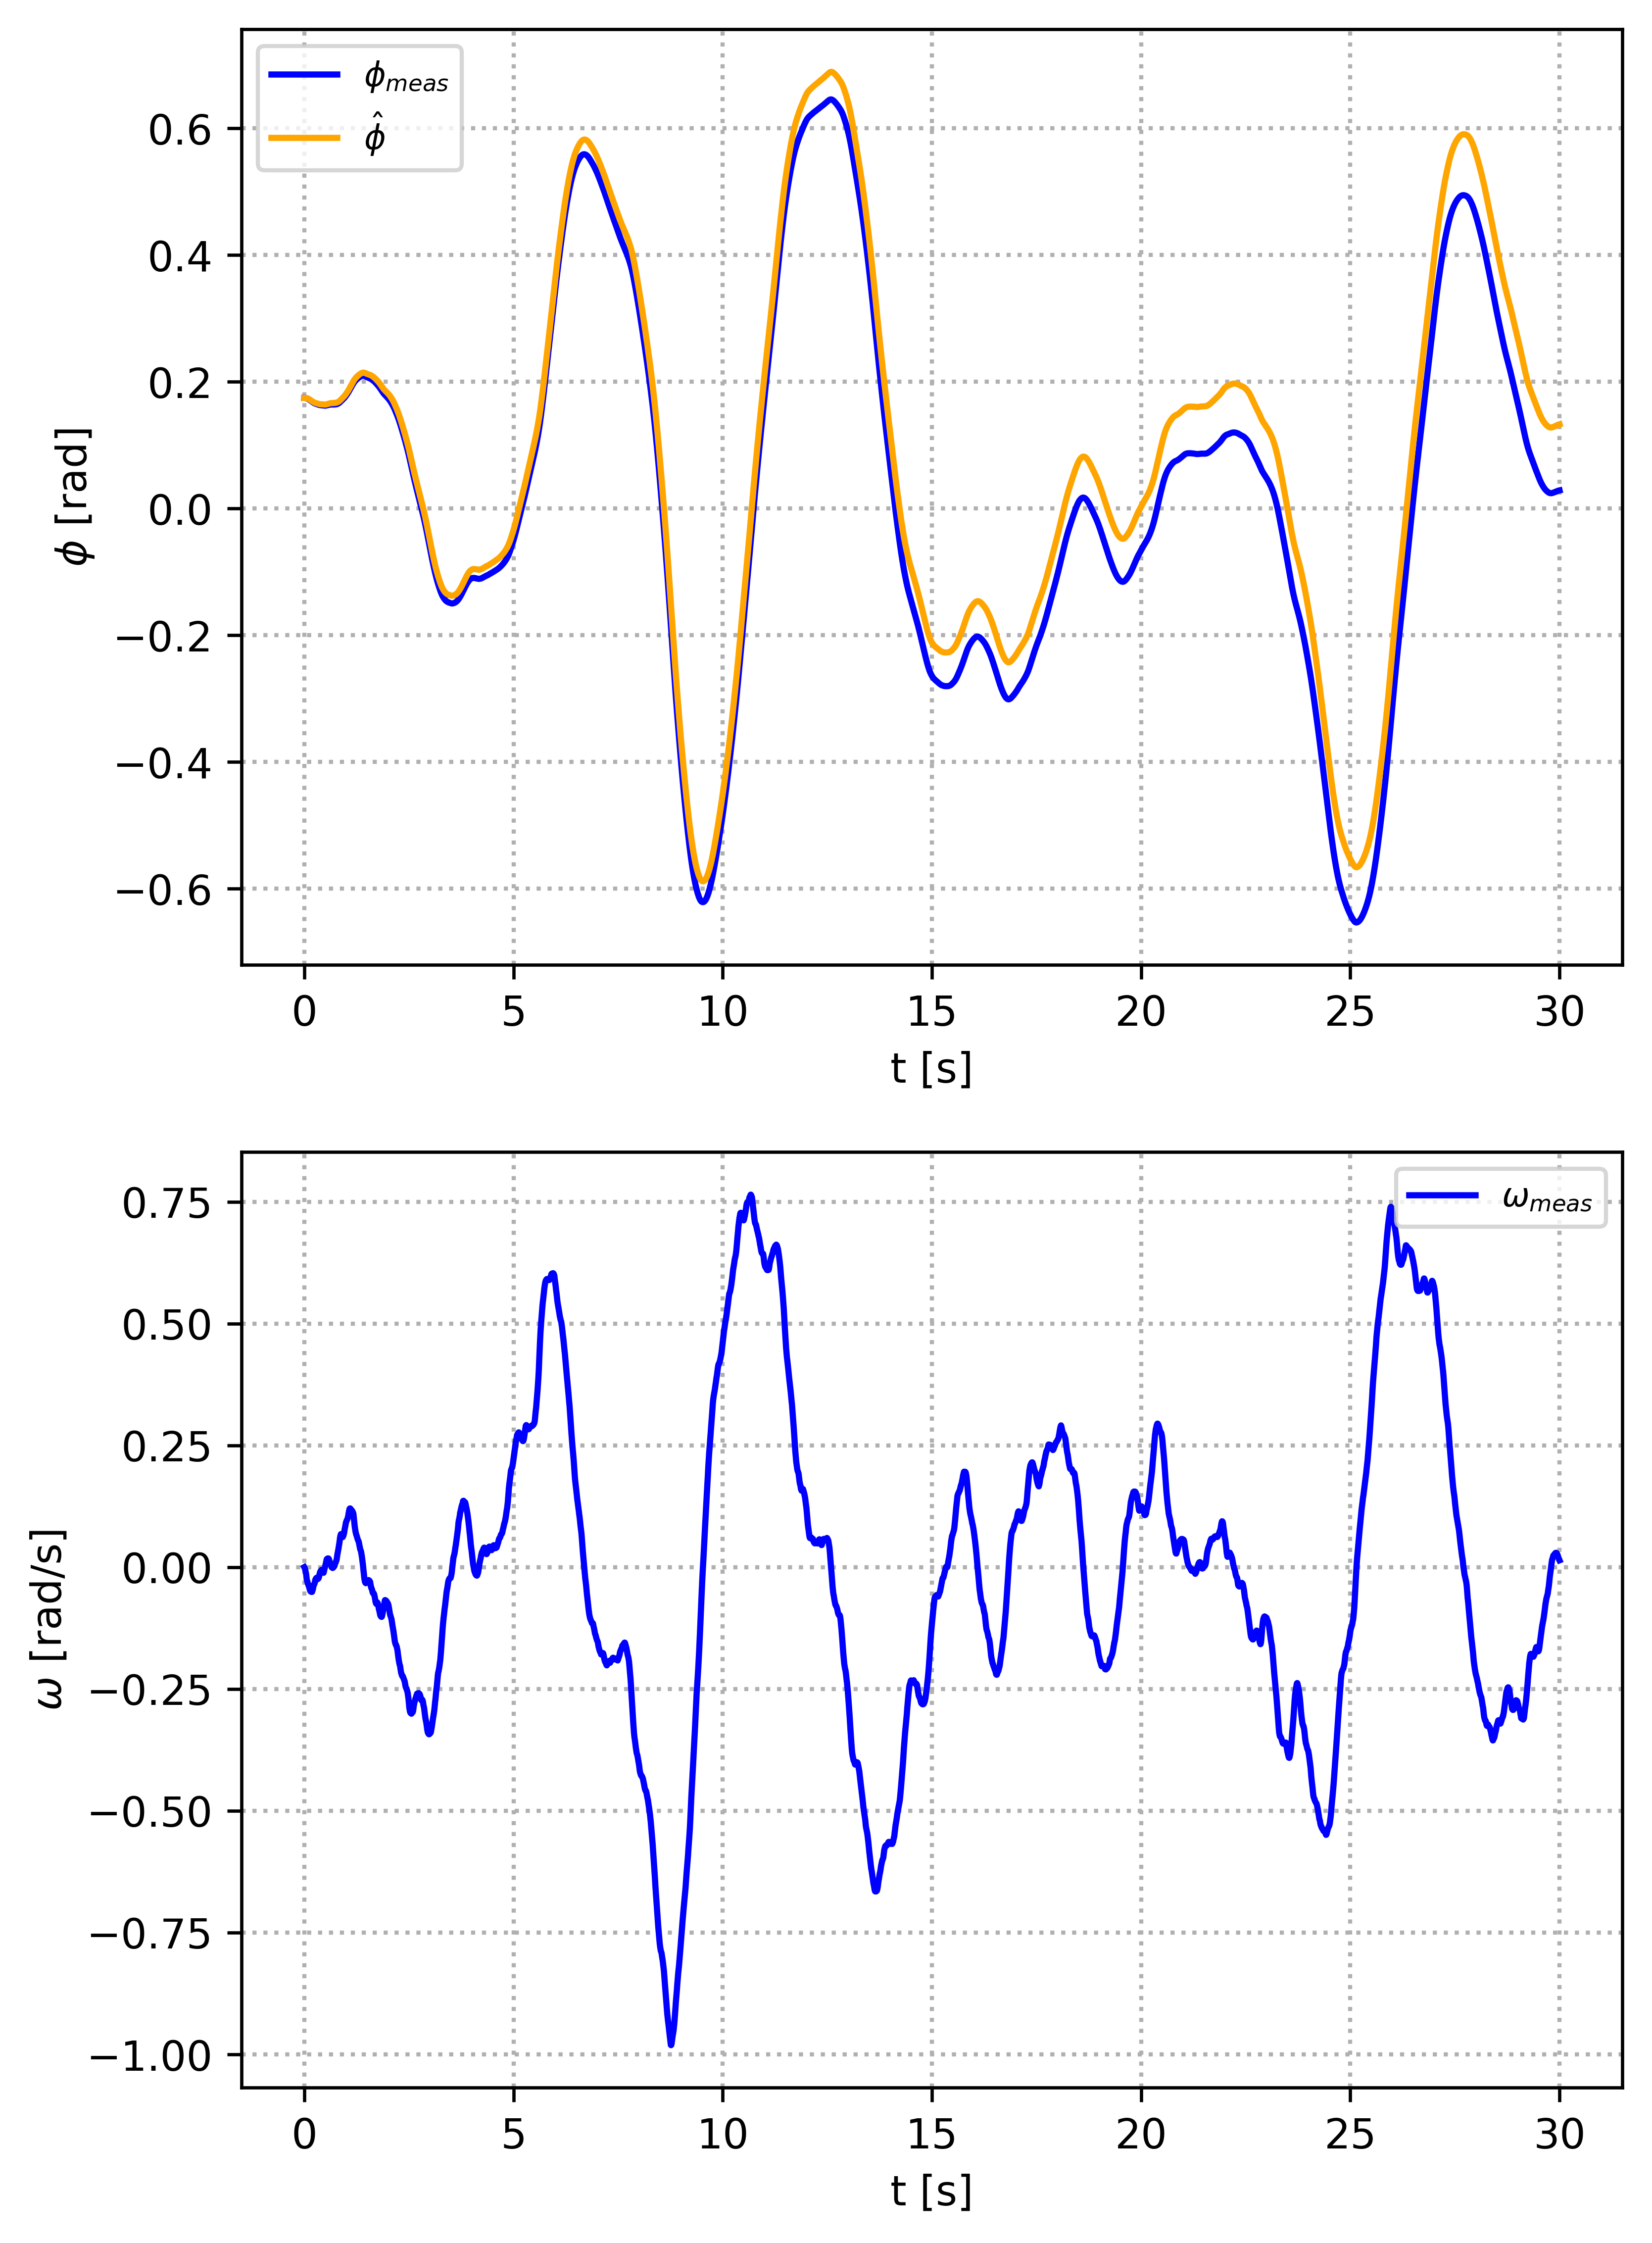

In [ ]:
fig, axs = plt.subplots(2,1,dpi=300,figsize=(6,9))

# phi
phi_hats = states[:,0].flatten()
axs[0].plot(sim['t'], sim['phi'], c='blue', label=r'$\phi_{meas}$')
axs[0].plot(sim['t'], z_angle, c='orange', label=r'$\hat{\phi}$')
axs[0].grid(lw=1, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi$ [rad]')
axs[0].legend(fontsize=8)

# # omega
omega_hats = states[:,1].flatten()
axs[1].plot(sim['t'], sim['omega'], c='blue', label=r'$\omega_{meas}$')
#axs[1].plot(sim['t'], z_rate, c='orange', label=r'$\hat{\omega}$')
#axs[1].set_ylim(-1000,1000)
axs[1].grid(lw=1, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\omega$ [rad/s]')
axs[1].legend(fontsize=8)

# bias
# alpha_hats = estimates_log[2:,2].flatten()
# axs[2].plot(sim['t'], sim['bias'], c='blue', label=r'$\alpha_{meas}$')
# axs[2].plot(sim['t']], alpha_hats, c='orange', label=r'$\hat{\alpha}$')
# axs[2].set_ylim(-1000,1000)
# axs[2].grid(lw=1, ls=':')
# axs[2].set_xlabel('t [s]')
# axs[2].set_ylabel(r'$\alpha$ [rad/s^2]')
# axs[2].legend(fontsize=8);